Part 1 Masked Mean 

In [1]:
import torch
B,T,C=2,4,3
x=torch.randn(B,T,C)
y = torch.tensor([
    [1, 0, 1, 1],
    [0, 1, 1, 0]
])
mask = y.unsqueeze(-1)
masked_x = x * mask
sum_x = masked_x.sum(dim=1)
count = mask.sum(dim=1)
mean_x = sum_x / count
print(mean_x.shape)
print(mean_x)

torch.Size([2, 3])
tensor([[ 0.0922, -0.9862, -0.5708],
        [-0.3102,  0.8174,  1.1641]])


Expanded Torch from (B,T) to (B,T,1) then multiplied with x and summed only valid positions

Part 2 Softmax from Scratch

In [2]:
x=torch.randn(5)
exp_x=torch.exp(x)
softmax_man=exp_x/exp_x.sum()
softmax_torch=torch.softmax(x,dim=0)
print(softmax_man)
print(softmax_torch)

print(torch.allclose(softmax_man, softmax_torch, atol=1e-6))

tensor([0.0750, 0.1137, 0.4100, 0.1775, 0.2238])
tensor([0.0750, 0.1137, 0.4100, 0.1775, 0.2238])
True


Naive Softmax is unstable because it causes very large value torch.exp(1000) to overflow The standard trick is subtracting the maximum value before exponentiation:

Part 3 

In [3]:
B, T, d = 2, 4, 3
Q = torch.randn(B, T, d)
K = torch.randn(B, T, d)
scores_einsum = torch.einsum(
    "btd,bsd->bts",
    Q,
    K
)

scores_matmul = Q @ K.transpose(-2, -1)
print(torch.equal(scores_einsum, scores_matmul))

True


Part 4 

In [4]:
import matplotlib.pyplot as plt
T = 8

mask = torch.triu(
    torch.ones(T, T),
    diagonal=1
)
mask = mask.masked_fill(mask == 1, float("-inf"))
mask = mask.masked_fill(mask == 0, 0)
print(mask)

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [5]:
scores = torch.randn(T, T)

masked_scores = scores + mask

attention = torch.softmax(masked_scores, dim=-1)

print(attention)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4902, 0.5098, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1036, 0.7847, 0.1117, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5837, 0.1751, 0.0702, 0.1711, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2458, 0.2370, 0.1775, 0.3117, 0.0279, 0.0000, 0.0000, 0.0000],
        [0.0275, 0.0909, 0.0351, 0.0260, 0.1871, 0.6336, 0.0000, 0.0000],
        [0.7023, 0.0051, 0.0939, 0.1294, 0.0347, 0.0127, 0.0219, 0.0000],
        [0.0553, 0.0520, 0.1043, 0.0765, 0.1679, 0.0324, 0.0612, 0.4503]])


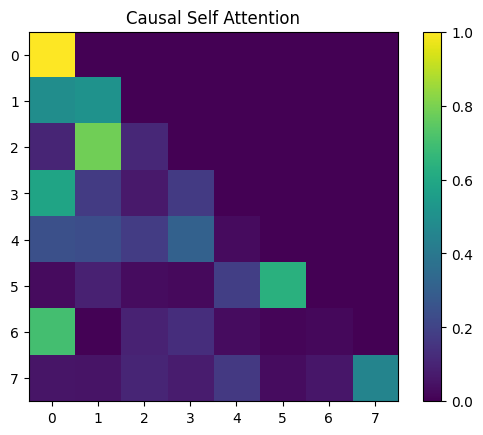

In [6]:
plt.imshow(attention.detach().numpy())

plt.colorbar()

plt.title("Causal Self Attention")

plt.show()

Part 5 LayerNorm

In [7]:
B, T, C = 2, 4, 5

x = torch.randn(B, T, C)

gamma = torch.ones(C)

beta = torch.zeros(C)

eps = 1e-5

mean = x.mean(dim=-1, keepdim=True)

var = x.var(dim=-1, unbiased=False, keepdim=True)

x_norm = (x - mean) / torch.sqrt(var + eps)

out_manual = gamma * x_norm + beta

In [8]:
layernorm = torch.nn.LayerNorm(C)

layernorm.weight.data = gamma

layernorm.bias.data = beta

out_torch = layernorm(x)

print(torch.allclose(out_manual, out_torch, atol=1e-5))

True


Part 6 

In [9]:
x = torch.randn(4, requires_grad=True)

y = (x ** 2).sum()

y.backward()

print("x:")
print(x)

print("autograd gradient:")
print(x.grad)

print("manual gradient:")
print(2 * x)

x:
tensor([-0.0981, -0.9977,  0.3992,  1.1931], requires_grad=True)
autograd gradient:
tensor([-0.1963, -1.9953,  0.7984,  2.3862])
manual gradient:
tensor([-0.1963, -1.9953,  0.7984,  2.3862], grad_fn=<MulBackward0>)


In [10]:
x = torch.randn(4, requires_grad=True)

y = torch.softmax(x, dim=0).sum()

y.backward()

print(x.grad)

tensor([-3.5460e-08, -1.4460e-08, -3.5846e-08, -3.3443e-08])
